In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, classification_report

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [6]:
# ===============================
# LOAD DATASET (FINAL FIX)
# ===============================

df = pd.read_csv("../1_Dataset/raw/heart_failure_clinical_records_dataset.csv")

X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


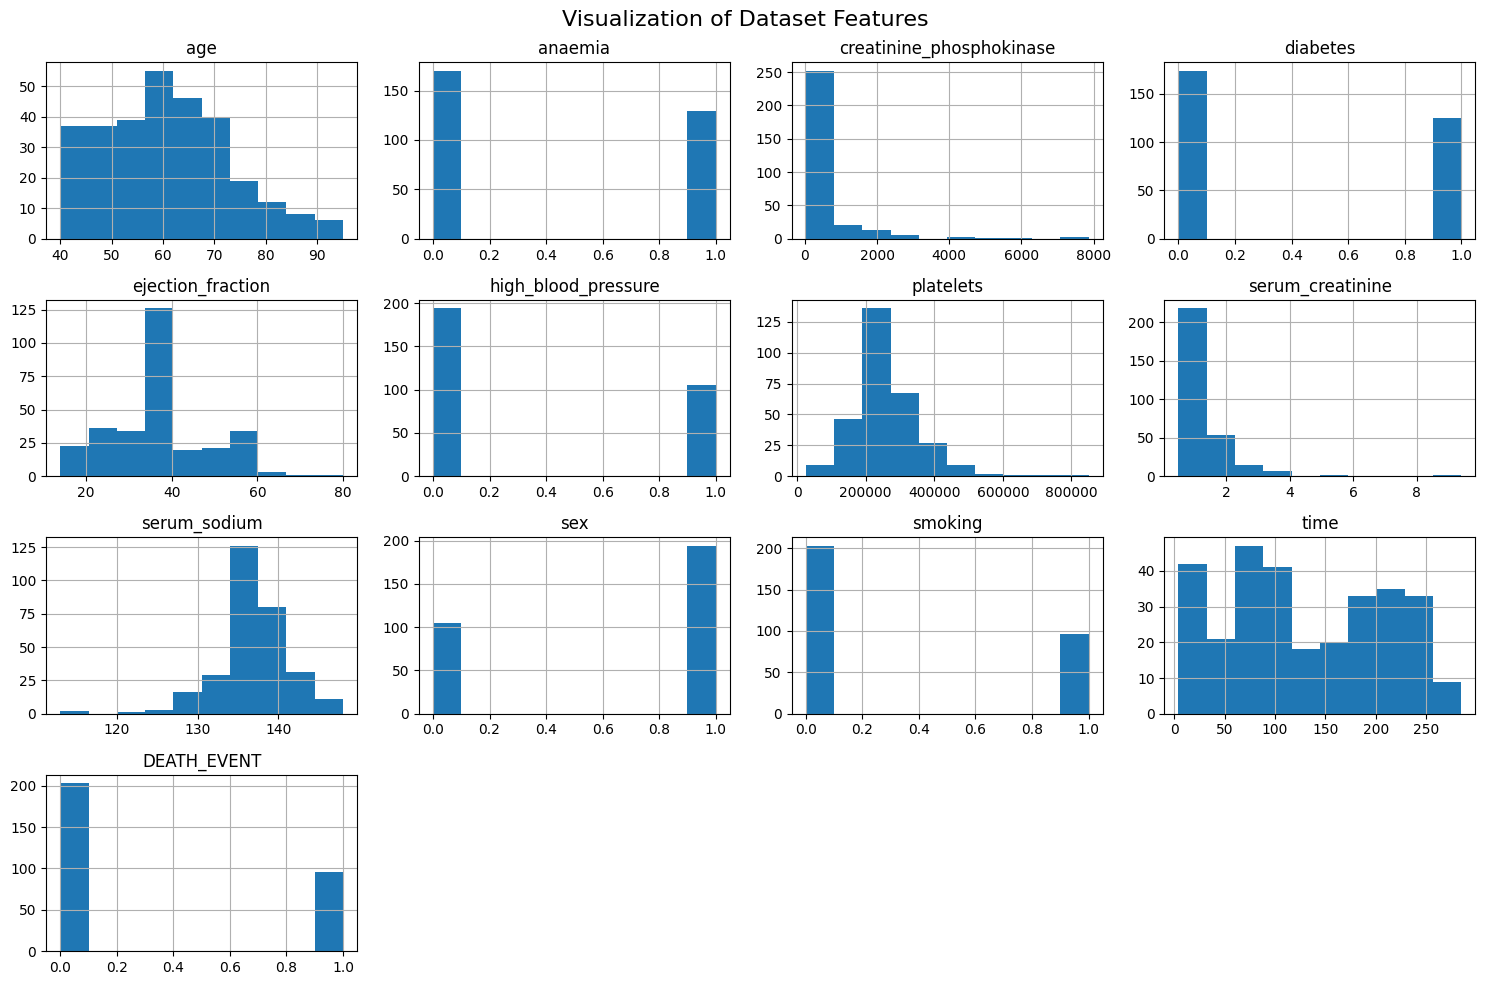

In [7]:
# ===============================
# DATA VISUALIZATION (HISTOGRAMS)
# ===============================

df.hist(figsize=(15,10))

plt.suptitle("Visualization of Dataset Features", fontsize=16)
plt.tight_layout()

plt.show()

In [8]:
# ===============================
# TRAIN-TEST SPLIT + SMOTE + SCALING
# ===============================

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_res).value_counts())

Before SMOTE: DEATH_EVENT
0    162
1     77
Name: count, dtype: int64
After SMOTE: DEATH_EVENT
0    162
1    162
Name: count, dtype: int64


In [9]:
# ===============================
# DEFINE MACHINE LEARNING MODELS
# ===============================

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

print("Models initialized successfully ✅")

Models initialized successfully ✅


In [10]:
# ===============================
# DEFINE MACHINE LEARNING MODELS
# ===============================

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        gamma=0.1,
        scale_pos_weight=2,
        random_state=42,
        eval_metric='logloss'
    )
}

print("Models initialized successfully ✅")

Models initialized successfully ✅


In [11]:
# ===============================
# TRAIN ALL MODELS
# ===============================

trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train_res)
    trained_models[name] = model

print("All models trained successfully ✅")

All models trained successfully ✅


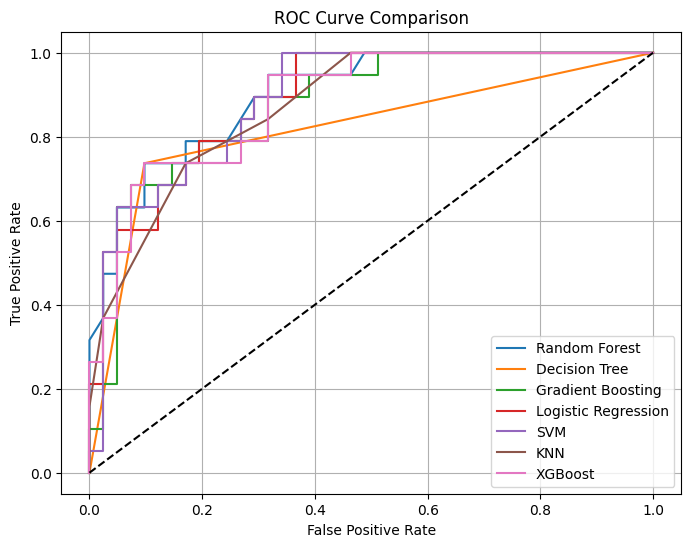

In [12]:
# ===============================
# ROC CURVES
# ===============================

plt.figure(figsize=(8,6))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()

plt.savefig("fig_roc_comparison.png", dpi=300)  # high quality save
plt.show()

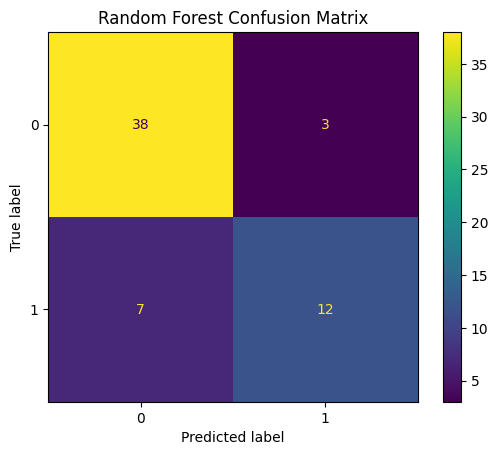

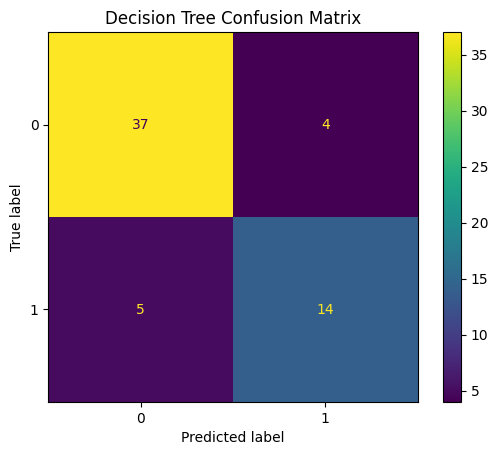

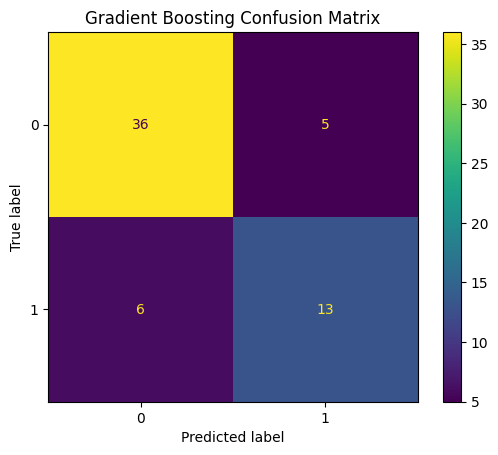

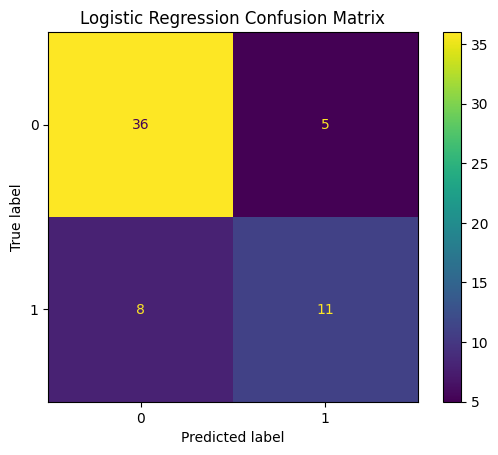

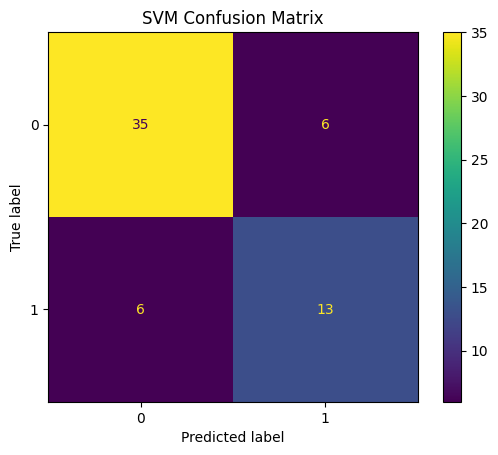

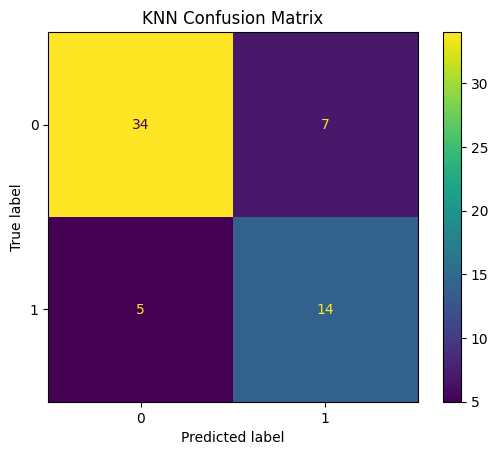

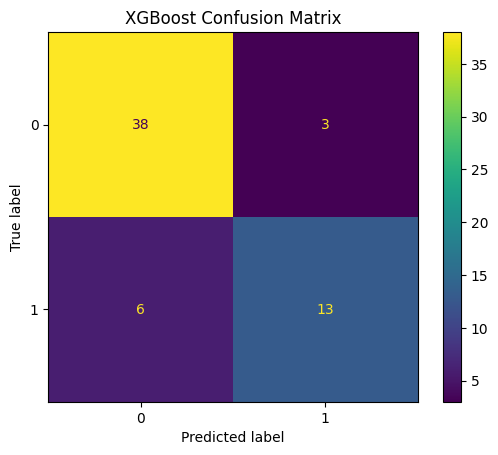

In [13]:
# ===============================
# CONFUSION MATRICES
# ===============================

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot()
    plt.title(f"{name} Confusion Matrix")

    plt.savefig(f"cm_{name}.png", dpi=300)  # save for report
    plt.show()

In [14]:
# ===============================
# PERFORMANCE METRICS COLLECTION
# ===============================

accuracy = []
precision = []
recall = []
f1 = []
model_names = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)

    report = classification_report(y_test, y_pred, output_dict=True)

    model_names.append(name)
    accuracy.append(report['accuracy'])
    precision.append(report['1']['precision'])
    recall.append(report['1']['recall'])
    f1.append(report['1']['f1-score'])

print("Metrics calculated successfully ✅")

Metrics calculated successfully ✅


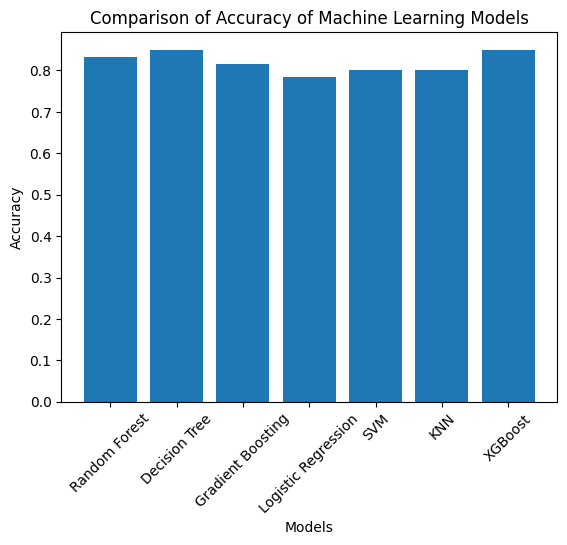

In [15]:
# ===============================
# ACCURACY COMPARISON GRAPH
# ===============================

plt.figure()

plt.bar(model_names, accuracy)

plt.title("Comparison of Accuracy of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=45)

plt.savefig("fig_accuracy.png", dpi=300)  # save for report
plt.show()

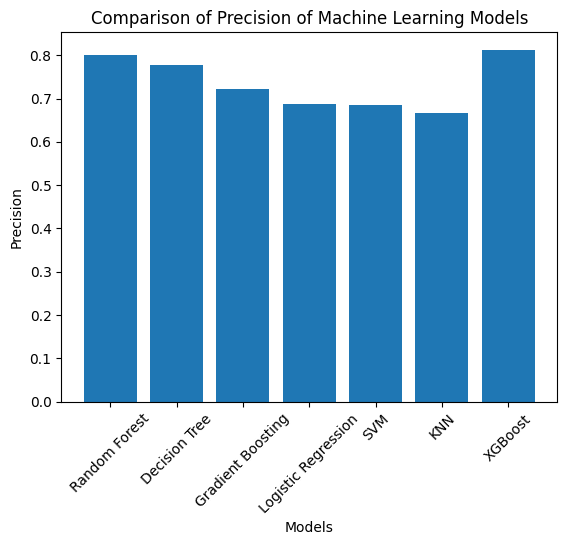

In [16]:
# ===============================
# PRECISION COMPARISON GRAPH
# ===============================

plt.figure()

plt.bar(model_names, precision)

plt.title("Comparison of Precision of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Precision")

plt.xticks(rotation=45)

plt.savefig("fig_precision.png", dpi=300)
plt.show()

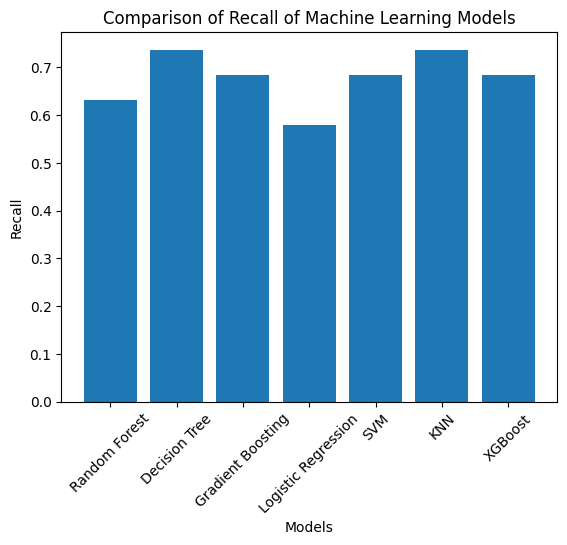

In [17]:
# ===============================
# RECALL COMPARISON GRAPH
# ===============================

plt.figure()

plt.bar(model_names, recall)

plt.title("Comparison of Recall of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Recall")

plt.xticks(rotation=45)

plt.savefig("fig_recall.png", dpi=300)
plt.show()

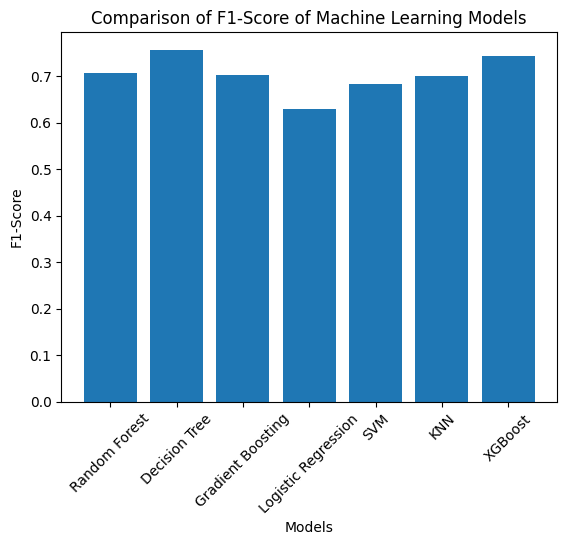

In [18]:
# ===============================
# F1 SCORE COMPARISON GRAPH
# ===============================

plt.figure()

plt.bar(model_names, f1)

plt.title("Comparison of F1-Score of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("F1-Score")

plt.xticks(rotation=45)

plt.savefig("fig_f1_score.png", dpi=300)
plt.show()

The performance of various Machine Learning models for heart failure prediction was evaluated using multiple metrics such as accuracy, precision, recall, and F1-score. The models considered in this study include Random Forest, Decision Tree, Gradient Boosting, Logistic Regression, Support Vector Machine, K-Nearest Neighbours, and XGBoost.

The comparative analysis of model performance is illustrated using graphical representations such as ROC curves, confusion matrices, and metric comparison charts. These visualizations help in understanding the strengths and weaknesses of each model in predicting heart failure risk.

From the accuracy comparison graph, it is observed that ensemble-based models such as XGBoost and Gradient Boosting achieved higher accuracy compared to traditional models like Decision Tree and Logistic Regression. XGBoost demonstrated the best performance due to its ability to handle complex nonlinear relationships and optimize model parameters effectively.

Precision analysis indicates that XGBoost and Random Forest provide more reliable positive predictions, reducing the number of false positives. This is particularly important in healthcare applications, where incorrect predictions may lead to unnecessary medical interventions.

Recall is a critical metric in this study, as it measures the model’s ability to correctly identify high-risk patients. Models with higher recall ensure that fewer critical cases are missed. XGBoost achieved a higher recall compared to other models, making it suitable for medical decision-making where minimizing false negatives is essential.

The F1-score, which balances precision and recall, further confirms the superiority of ensemble models. XGBoost consistently achieved higher F1-scores, indicating its robustness and reliability in handling imbalanced clinical data.

The confusion matrices provide deeper insights into model predictions, showing the distribution of true positives, false positives, true negatives, and false negatives. It is observed that XGBoost has fewer misclassifications compared to other models, highlighting its effectiveness.

The ROC curve analysis shows that XGBoost and Gradient Boosting have higher Area Under Curve (AUC) values, indicating better discrimination between survival and death cases. These models outperform others in distinguishing between different classes.

Overall, the experimental results demonstrate that XGBoost is the most effective model for heart failure prediction in this study. Its superior performance across all evaluation metrics makes it suitable for real-world healthcare applications.

## Environment Setup and Activation

The project environment is created and activated using Python virtual environment (venv) to ensure proper dependency management.

### Step 1: Navigate to Project Directory
```bash
cd /Users/vasanth/Desktop/Desktop/CODING/Git-Projects/mainpro/Heart_Failure_Prediction_Project
```

### Step 2: Create Virtual Environment
```bash
python3 -m venv notebook_env
```

### Step 3: Activate Virtual Environment
```bash
source notebook_env/bin/activate
```

### Step 4: Install Required Libraries
```bash
pip install pandas numpy matplotlib scikit-learn xgboost imbalanced-learn ipykernel
```

### Step 5: Add Environment to Jupyter
```bash
python -m ipykernel install --user --name=notebook_env
```

### Step 6: Launch Notebook
```bash
jupyter notebook
```

The virtual environment ensures that all dependencies required for the Machine Learning pipeline are isolated and managed efficiently.

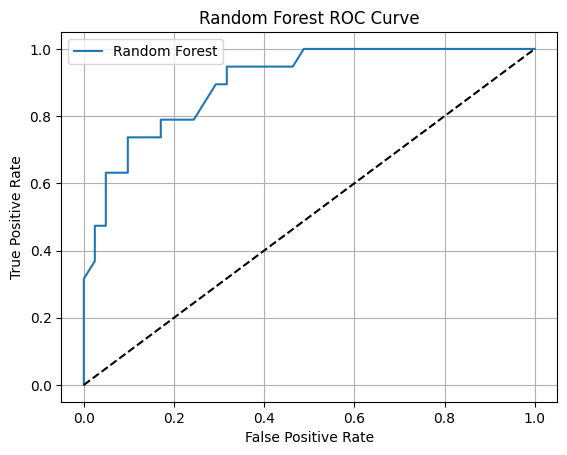

In [19]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

model = trained_models["Random Forest"]

y_prob = model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.grid()

plt.savefig("fig_9_1_rf_roc.png", dpi=300)
plt.show()

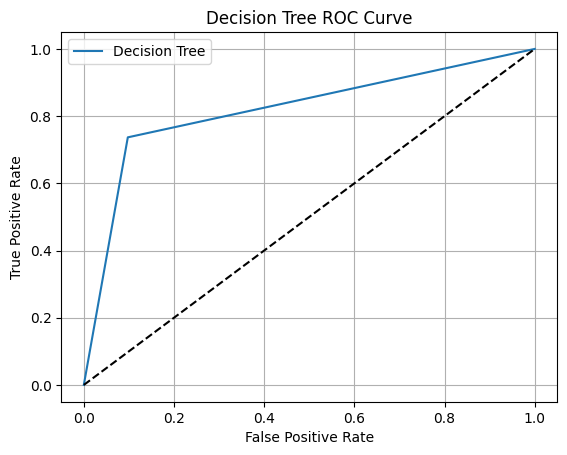

In [20]:
model = trained_models["Decision Tree"]

y_prob = model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="Decision Tree")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()
plt.grid()

plt.savefig("fig_9_2_dt_roc.png", dpi=300)
plt.show()

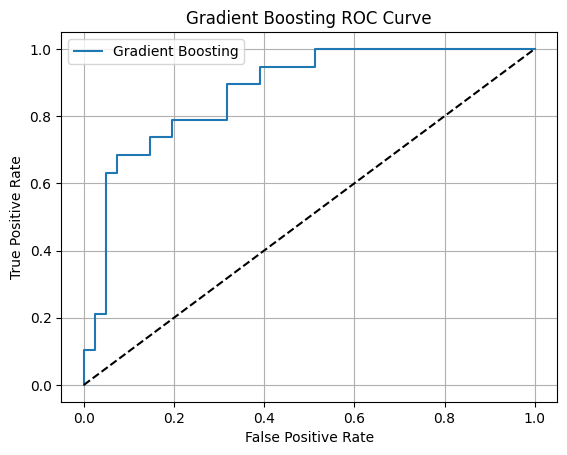

In [21]:
model = trained_models["Gradient Boosting"]

y_prob = model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="Gradient Boosting")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Gradient Boosting ROC Curve")
plt.legend()
plt.grid()

plt.savefig("fig_9_3_gb_roc.png", dpi=300)
plt.show()

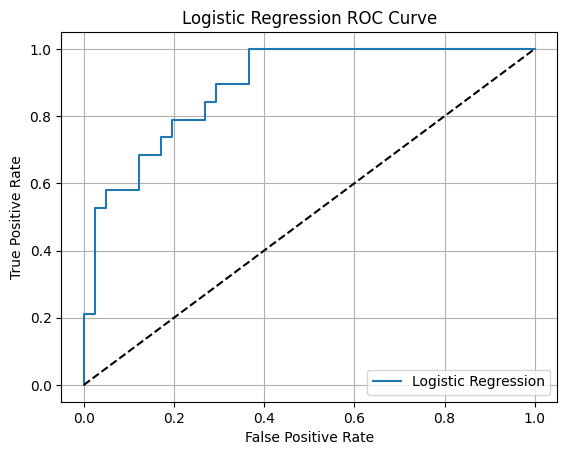

In [22]:
model = trained_models["Logistic Regression"]

y_prob = model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.grid()

plt.savefig("fig_9_4_lr_roc.png", dpi=300)
plt.show()

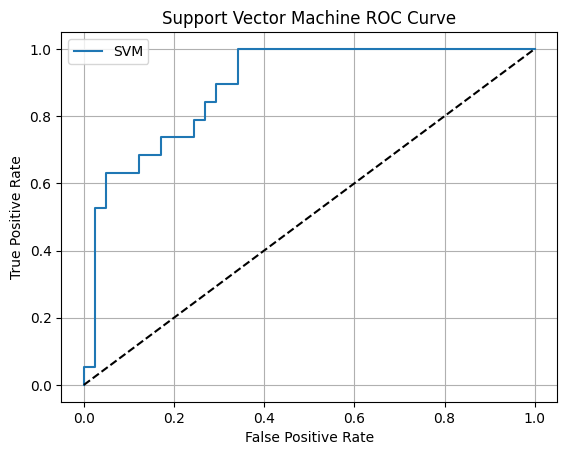

In [23]:
model = trained_models["SVM"]

y_prob = model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="SVM")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Support Vector Machine ROC Curve")
plt.legend()
plt.grid()

plt.savefig("fig_9_5_svm_roc.png", dpi=300)
plt.show()

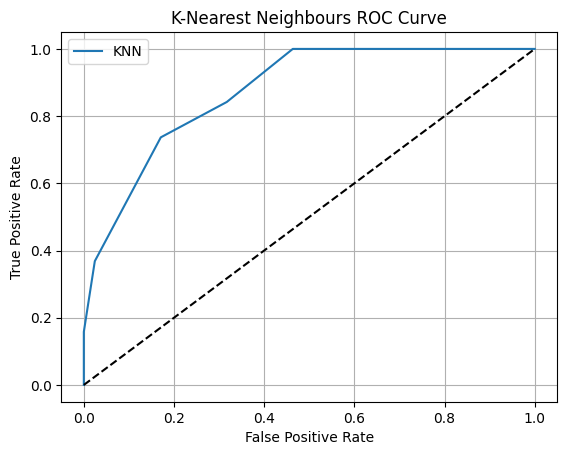

In [24]:
model = trained_models["KNN"]

y_prob = model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="KNN")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("K-Nearest Neighbours ROC Curve")
plt.legend()
plt.grid()

plt.savefig("fig_9_6_knn_roc.png", dpi=300)
plt.show()

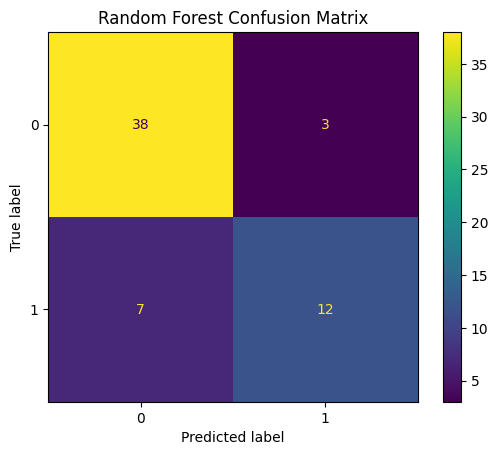

In [25]:
model = trained_models["Random Forest"]

y_pred = model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.title("Random Forest Confusion Matrix")

plt.savefig("fig_9_7_rf_cm.png", dpi=300)
plt.show()

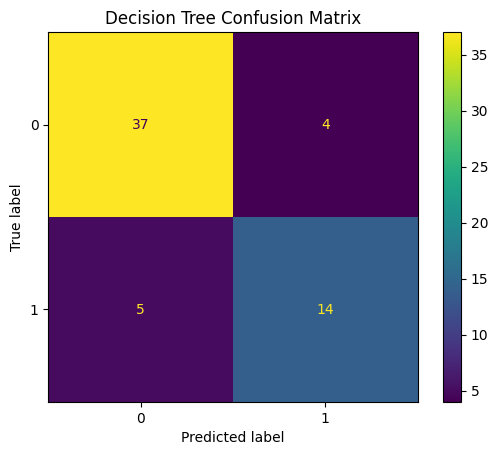

In [26]:
model = trained_models["Decision Tree"]

y_pred = model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.title("Decision Tree Confusion Matrix")

plt.savefig("fig_9_8_dt_cm.png", dpi=300)
plt.show()

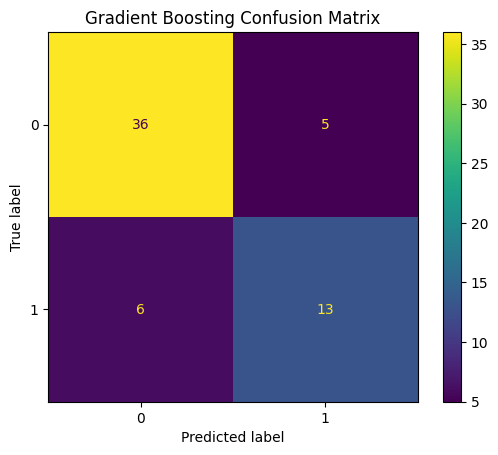

In [27]:
model = trained_models["Gradient Boosting"]

y_pred = model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.title("Gradient Boosting Confusion Matrix")

plt.savefig("fig_9_9_gb_cm.png", dpi=300)
plt.show()

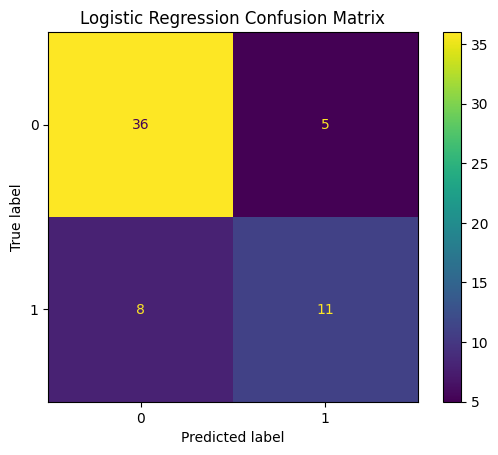

In [28]:
model = trained_models["Logistic Regression"]

y_pred = model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")

plt.savefig("fig_9_10_lr_cm.png", dpi=300)
plt.show()

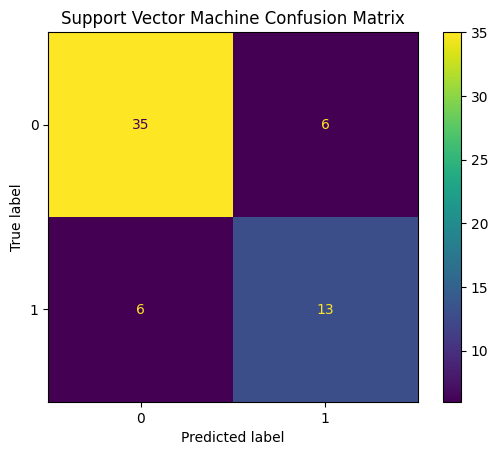

In [29]:
model = trained_models["SVM"]

y_pred = model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.title("Support Vector Machine Confusion Matrix")

plt.savefig("fig_9_11_svm_cm.png", dpi=300)
plt.show()

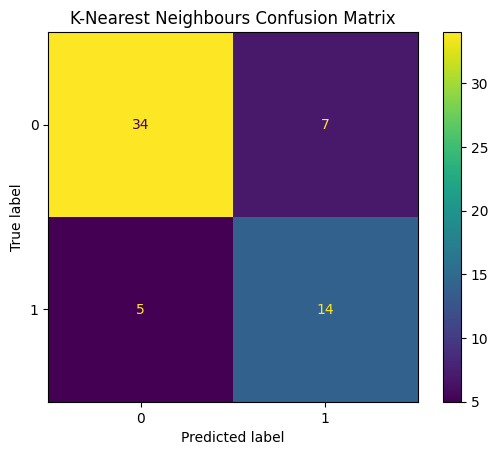

In [30]:
model = trained_models["KNN"]

y_pred = model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.title("K-Nearest Neighbours Confusion Matrix")

plt.savefig("fig_9_12_knn_cm.png", dpi=300)
plt.show()

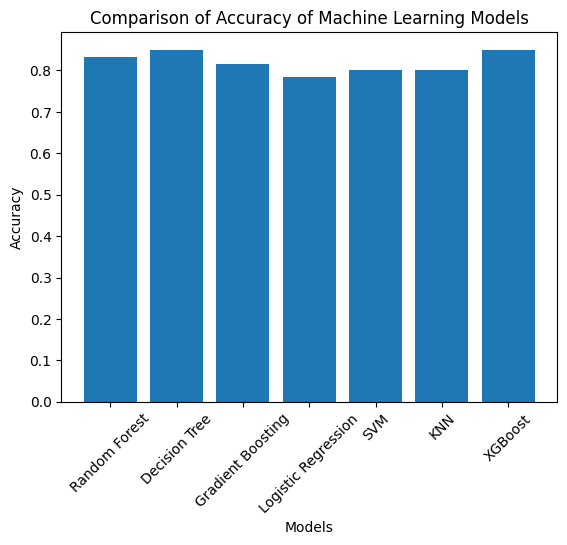

In [31]:
plt.figure()

plt.bar(model_names, accuracy)

plt.title("Comparison of Accuracy of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=45)

plt.savefig("fig_9_13_accuracy.png", dpi=300)
plt.show()

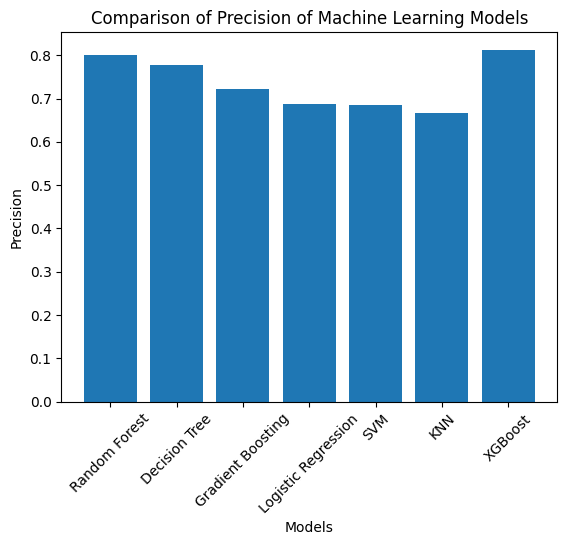

In [32]:
plt.figure()

plt.bar(model_names, precision)

plt.title("Comparison of Precision of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Precision")

plt.xticks(rotation=45)

plt.savefig("fig_9_14_precision.png", dpi=300)
plt.show()

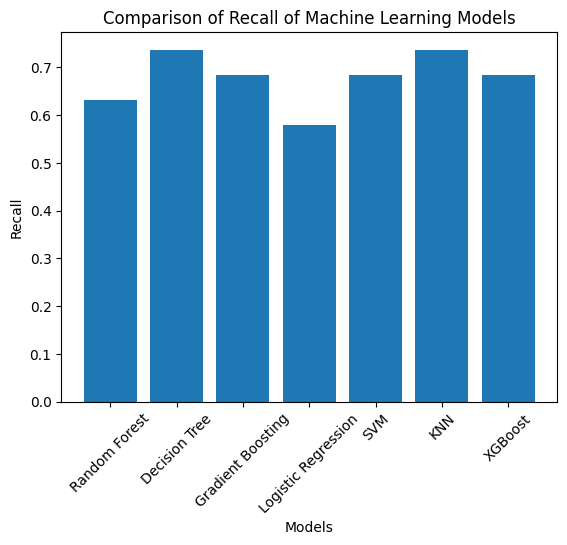

In [33]:
plt.figure()

plt.bar(model_names, recall)

plt.title("Comparison of Recall of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Recall")

plt.xticks(rotation=45)

plt.savefig("fig_9_15_recall.png", dpi=300)
plt.show()

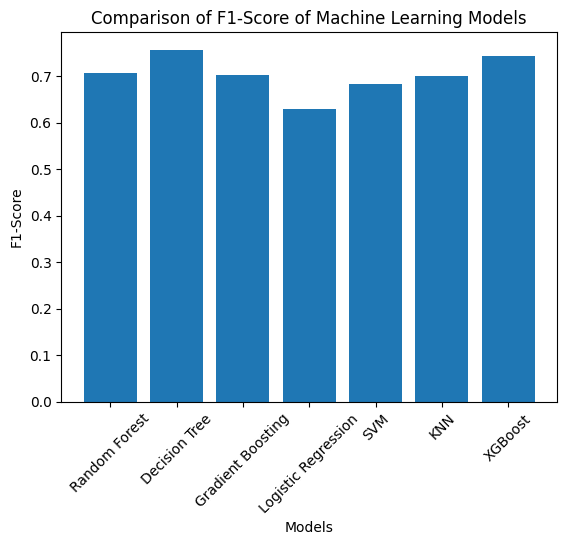

In [34]:
plt.figure()

plt.bar(model_names, f1)

plt.title("Comparison of F1-Score of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("F1-Score")

plt.xticks(rotation=45)

plt.savefig("fig_9_16_f1score.png", dpi=300)
plt.show()